In [1]:
# 변수의 shape, type, value 확인
def p(var,_name="") :
    if _name != "" : print(f'<<{_name}>>')
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}')

def pst(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'<<{_name}>> Shape{_x.shape}')

# Semantic Search Engine(RAG) Agent

In [2]:
#!pip install langchain pydantic sentence-transformers
!pip install langchain-openai faiss-cpu hnswlib -q

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# Wall time: 40.3 s

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.5/82.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 471.5/471.5 kB 26.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.0.5 which is incompatible.


In [3]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')

NotebookAccessError: Notebook does not have access to secret OPENAI_API_KEY

In [ ]:
!pip install langchain-community pypdf
# google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.

In [ ]:
!pip list | grep -E "langchain|langchain-openai|langchain-community|sentence-transformers|faiss-cpu|pypdf"
# 25.09
# faiss-cpu                             1.12.0
# langchain                             0.3.27
# langchain-community                   0.3.30
# langchain-core                        0.3.76
# langchain-openai                      0.3.33
# langchain-text-splitters              0.3.11
# pypdf                                 6.1.0
# sentence-transformers                 5.1.0

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

In [ ]:
data_path = "/content/gdrive/MyDrive/Colab Notebooks/datasets/LLM"
manual_path = os.path.join(data_path, "manuals")

In [ ]:
import getpass
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_API_KEY"] = userdata.get('LANGSMITH_API_KEY')

## LangChain Document의 텍스트 관련 데이터 세가지 속성
https://python.langchain.com/api_reference/core/documents.html
   
    page_content: 콘텐츠를 나타내는 문자열
    metadata: 임의의 메타데이터를 포함하는 dict
    id: (선택 사항) 문서의 문자열 식별자


* `메타데이터` attribute : 문서의 출처, 다른 문서와의 관계, 기타 정보를 가짐
* `Document` object : 종종 더 큰 문서의 일부 임

In [ ]:
from langchain_core.documents import Document

documents = [
    Document(
        page_content="Dogs are great companions, known for their loyalty and friendliness.",
        metadata={"source": "mammal-pets-doc"},
    ),
    Document(
        page_content="Cats are independent pets that often enjoy their own space.",
        metadata={"source": "mammal-pets-doc"},
    ),
]

## PDF Loader

* 다양한 문서 Lader : https://docs.langchain.com/oss/python/integrations/document_loaders#pdfs  
* PDF Loader  

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

file_name = "nke-10k-2023.pdf"
file_name = "반도체 제조공정의 안전작업에 관한 기술지침.pdf"
#ile_name = "SP00.pdf"
file_path = manual_path+'/'+file_name
loader = PyPDFLoader(file_path)

docs = loader.load()

print(len(docs))

In [ ]:
print(f"{docs[0].page_content[:200]}\n")
print(docs[0].metadata)

In [ ]:
docs

[ Document(    
    metadata={  
    'producer': 'ezPDF Builder Supreme', 'creator': 'PyPDF', 'creationdate': '2020-12-18T04:30:00+09:00', 'moddate': '2020-12-18T04:30:00+09:00', 'source': '/content/gdrive/MyDrive/Colab Notebooks/datasets/LLM/manuals/반도체 제조공정의 안전작업에 관한 기술지침.pdf', 'total_pages': 15, 'page': 0, 'page_label': '1'  
    },    
  page_content=  
    'KOSHA GUIDE\nP-127-2012\n반도체 제조공정의 안전작업에 관한\n기술지침\n2012. 11\n한국산업안전보건공단'
  ),  

Document(  
  metadata={  
     'producer': 'ezPDF Builder Supreme', 'creator': 'PyPDF', 'creationdate': '2020-12-18T04:30:00+09:00', 'moddate': '2020-12-18T04:30:00+09:00', 'source': '/content/gdrive/MyDrive/Colab Notebooks/datasets/LLM/manuals/반도체 제조공정의 안전작업에 관한 기술지침.pdf', 'total_pages': 15, 'page': 1, 'page_label': '2'  
     },     
  page_content=  
    '안전보건기술지침의 개요\n◦ 작성자 : 한우섭\no 제정 경과\n- 2012년 11월 화학안전분야 제정위원회 심의\no 관련규격 및 자료\n- 化学工業における爆發火災防止対策, 中央勞働災害防止協會 (2004).\n- 半導体製造工程における安全衛生対策指針の解説, 化学物質安全情報センター\n(1988)\n◦ 기술지침의 적용 및 문의\n   이 기술지침에 대한 의견 또는 문의는 한국산업안전보건공단 홈페이지 안전보건\n기술지침 소관 분야별 문의처 안내를 참고하시기 바랍니다.\n공표일자: 2012년 11월 29일\n제 정 자: 한국산업안전보건공단 이사장'  
),    

Document(  
  metadata={  
    'producer': 'ezPDF Builder Supreme', 'creator': 'PyPDF', 'creationdate': '2020-12-18T04:30:00+09:00', 'moddate': '2020-12-18T04:30:00+09:00', 'source': '/content/gdrive/MyDrive/Colab Notebooks/datasets/LLM/manuals/반도체 제조공정의 안전작업에 관한 기술지침.pdf', 'total_pages': 15, 'page': 2, 'page_label': '3'  
    },   
  page_content=  
    'KOSHA GUIDE\nP-127-2012\n- 1 -\n   반도체 제조공정의 안전작업에 관한 기술지침\n1. 목적\n이 기술지침은 반도체 제조공정에서 화재폭발 사고방지를 위해 요구되는 설비의 기\n준, 재료, 고압용기 등의 안전 취급 작업과 유지 보수의 기준, 그리고 비상 대응책\n등의 안전에 필요한 사항을 제시하고 공정설비의 본질적 안전, 검사 체제와 작업\n관리 확립에 필요한 기술적 사항을 제공하는데 그 목적이 있다.\n2. 적용범위\n이 지침은 반도체제조공정 또는 반도체용가스를 사용하는 경우에 적용한다.\n3. 정 의\n(1) 이 지침에서 사용하는 용어의 뜻은 다음과 같다\n(가) “반도체 제조 공정”이라 함은 집적 회로를 제조하는 반도체칩 제조 공정 중에\n서 적층성장(Epitaxial Growth), 산화, 사진식각공정(Photolithography), 에칭,\n불순물 확산, 이온 주입, 화학증기증착(CVD ; Chemical Vaper Deposition), 증\n착·스퍼터(Sputter) 등의 공정을 말한다.\n(나) “반도체용가스"라 함은 반도체공정에서 사용되는 모든 가스를 말한다.\n(다) “특수재료가스"라 함은 반도체용가스 중에서 실란(SiH4), 디실란(Si2H6), 포스핀\n(PH3), 아르신(ASH3), 디보란(B2H6) 등과 같이 주로 반도체 디바이스의 재료\n에 사용되는 가스를 말한다.'),  


## Vector Query

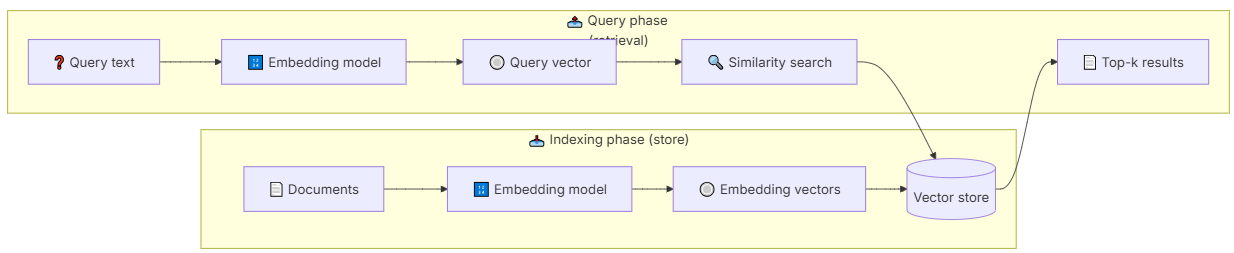

### Text Splitter  

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500, chunk_overlap=100, add_start_index=True
)
all_splits = text_splitter.split_documents(docs)

len(all_splits)

In [ ]:
p(all_splits[3])

### Embedding Models  
* 지원하는 Embedding 모델 : https://docs.langchain.com/oss/python/integrations/text_embedding    
  OpenAI Azure Google Gemini Google Vertex AWS HuggingFace Ollama Cohere MistralAI Nomic NVIDIA Voyage AI IBM watsonx Fake



In [ ]:
!pip install -U "langchain-openai" -q

In [ ]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

In [ ]:
p(all_splits[0].page_content)
print("="*20)
p(all_splits[1].page_content)

In [ ]:
vector_1 = embeddings.embed_query(all_splits[0].page_content)
vector_2 = embeddings.embed_query(all_splits[1].page_content)

assert len(vector_1) == len(vector_2)
print(f"Generated vectors of length {len(vector_1)}\n")
print(vector_1[:10])

### Vector Store :
 https://docs.langchain.com/oss/python/integrations/vectorstores       
* 일반 Text 및 `Document` 객체를 저장하고, 유사한 정보를 query하는 methods를 제공함   
* 지원하는 Vector Store:    
   In-memory AstraDB Chroma FAISS Milvus MongoDB PGVector PGVectorStore Pinecone Qdrant  

In [ ]:
#!pip install -U "langchain-core" # 설치되어 있음
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

#### Vector Store Methods       
https://python.langchain.com/api_reference/core/vectorstores/langchain_core.vectorstores.base.VectorStore.html#langchain_core.vectorstores.base.VectorStore

* 동기식과 비동기식  
* 문자열과 벡터로 쿼리
* 유사도 점수를 반환하는 경우와 반환하지 않는 경우
* 유사성과 최대 주변 관련성 (검색된 결과에서 유사성과 쿼리의 다양성을 균형 있게 조정).

| Methodes | Description |  
|----------|----------|
|aadd_documents(documents, **kwargs) | Async run more documents through the embeddings and add to the vectorstore. |  
| aadd_texts(texts[, metadatas, ids]) | Async run more texts through the embeddings and add to the vectorstore. |  
| **add_documents**(documents, **kwargs) | Add or update documents in the vectorstore.|  
| **add_texts**(texts[, metadatas, ids]) | Run more texts through the embeddings and add to the vectorstore.|  
| adelete([ids]) | Async delete by vector ID or other criteria.|  
| afrom_documents(documents, embedding, **kwargs) |  Async return VectorStore initialized from documents and embeddings. |  
|  afrom_texts(texts, embedding[, metadatas, ids]) |  Async return VectorStore initialized from texts and embeddings. |  
 |  aget_by_ids(ids, /) |  Async get documents by their IDs. |  amax_marginal_relevance_search(query[, k, ...])|  Async return docs selected using the maximal marginal relevance.|  
|  amax_marginal_relevance_search_by_vector(...)|  Async return docs selected using the maximal marginal relevance.|  
|  **as_retriever**(**kwargs)|  Return VectorStoreRetriever initialized from this VectorStore.
|  asearch(query, search_type, **kwargs)|  Async return docs most similar to query using a specified search type.|  
|  asimilarity_search(query[, k])|  Async return docs most similar to query.|  
|  asimilarity_search_by_vector(embedding[, k])|  Async return docs most similar to embedding vector.|  
|  asimilarity_search_with_relevance_scores(query)|  Async return docs and relevance scores in the range [0, 1].|  
|  asimilarity_search_with_score(*args, **kwargs)|  Async run similarity search with distance.|  
|  **delete**([ids])|  Delete by vector ID or other criteria.|  
|  **from_documents**(documents, embedding, **kwargs)|  Return VectorStore initialized from documents and embeddings.|  
|  **from_texts**(texts, embedding[, metadatas, ids])|  Return VectorStore initialized from texts and embeddings.|  
|  **get_by_ids**(ids, /)|  Get documents by their IDs.|  
|  **max_marginal_relevance_search**(query[, k, ...])|  Return docs selected using the maximal marginal relevance.|  
|  **max_marginal_relevance_search_by_vector**(...)| Return docs selected using the maximal marginal relevance.|  
|  **search**(query, search_type, **kwargs)|  Return docs most similar to query using a specified search type.|  
|  **similarity_search**(query[, k])|  Return docs most similar to query.|  
|  **similarity_search_by_vector**(embedding[, k])|  Return docs most similar to embedding vector.|  
|  similarity_search_with_relevance_scores(query)|  Return docs and relevance scores in the range [0, 1].|  
|  **similarity_search_with_score**(*args, **kwargs)|   Run similarity search with distance.|  

In [ ]:
ids = vector_store.add_documents(documents=all_splits)

In [ ]:
p(ids) # ids : List of IDs of the added texts.

* **max_marginal_relevance_search**

```python
## max_marginal_relevance_search ##
docs = vector_store.max_marginal_relevance_search(
    query="AI chip market",
    k=5,              # 최종적으로 가져올 문서 개수
    fetch_k=20,       # 먼저 20개 후보 뽑고
    lambda_mult=0.7 ) # 관련성 70%, 다양성 30% 가중치
```

#### similarity_search

In [ ]:
results = vector_store.similarity_search(
    query = "안전작업에 관한 기술지침", k = 4 )

In [ ]:
p(results[0])

In [ ]:
for i in range(4):
  print("="*20)
  print(results[i])

#### similarity_search_with_score

In [ ]:
results = vector_store.similarity_search_with_score("안전작업에 관한 기술지침", k = 4 )
doc, score = results[0]
print(f"Score: {score}\n")
print(doc)

In [ ]:
for i in range(4):
  doc, score = results[i]
  print(f"======= Score: {score}\n")
  print(doc)

#### similarity_search_by_vector

In [ ]:
#embedding = embeddings.embed_query("How were Nike's margins impacted in 2023?")
results = vector_store.similarity_search_by_vector(vector_1)
print(results[0])

### Retrievers

In [ ]:
## BM25Retriever 사용예 ##
#!pip install rank_bm25
from langchain_community.retrievers import BM25Retriever

docs = ["apple quarterly earnings report shows strong growth",
        "apple pie recipe with cinnamon and sugar"]

retriever = BM25Retriever.from_texts(docs)
results = retriever.get_relevant_documents("apple earnings report")

for r in results:
    print(r.page_content)

In [ ]:
p(results)